<a href="https://colab.research.google.com/github/sirlobardo/COOPER-9/blob/master/acionamentos_trabalho_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho CRG-AUT-044 - Acionamentos Elétricos


In= 100.68176914037694
           Método      Torque    Corrente  Atende
0  Partida direta  219.014898  754.556179    True
1        Soft 80%  140.169535  603.644943   False
2        V/f 60Hz  219.014898  754.556179    True


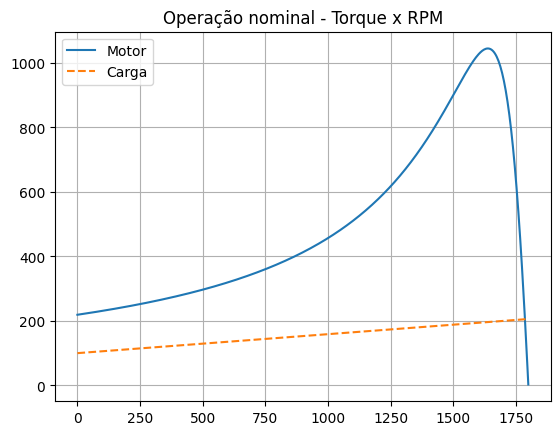

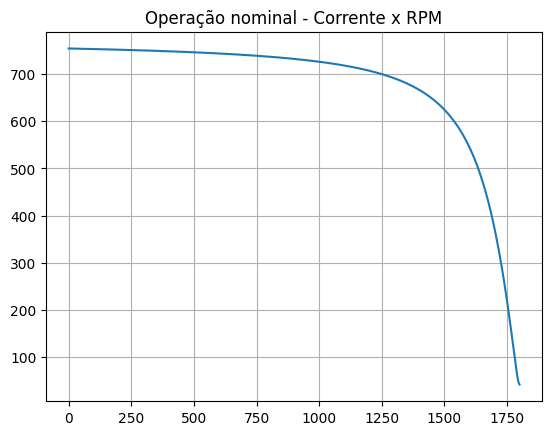

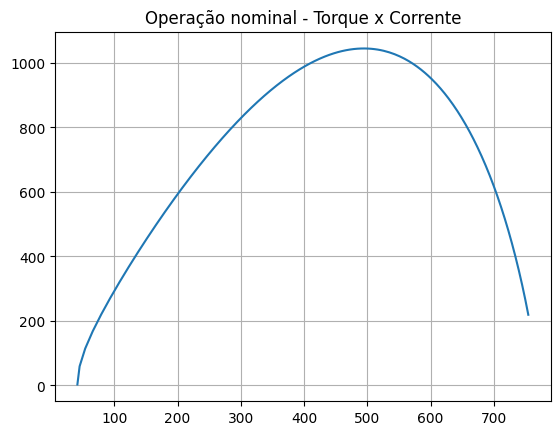

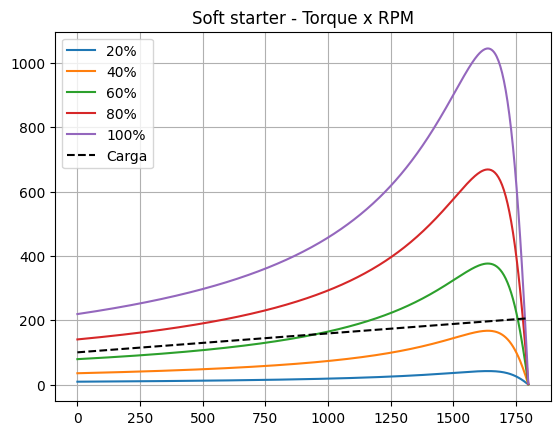

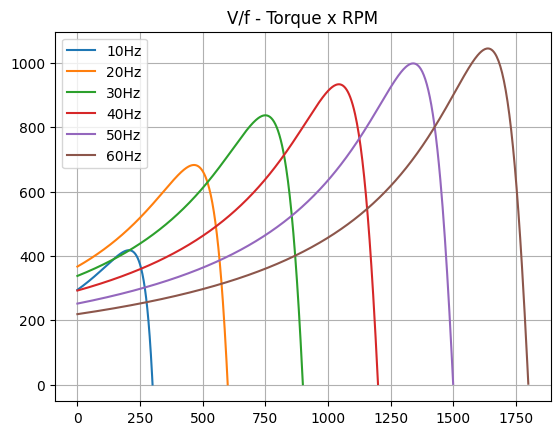

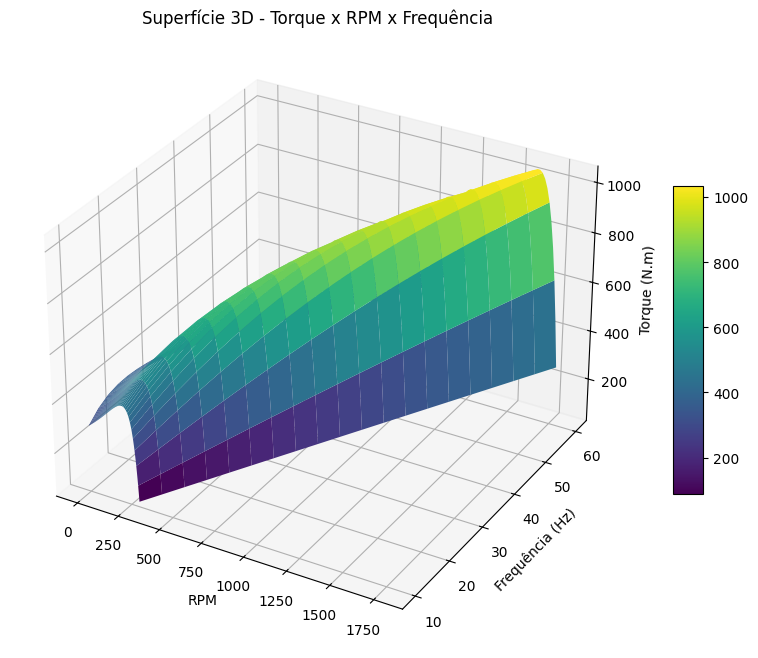

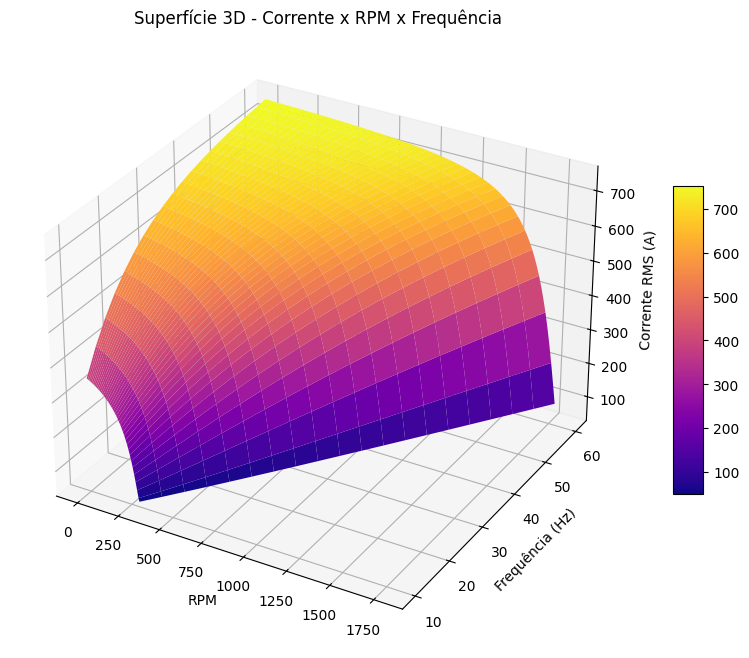

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
Rs=0.0669; Ls=0.000371; Lm=0.013589; Lr=0.000371; Rr=0.025508
Vll_nom=380; f_nom=60; poles=4; Pn=55000; eff=0.954; pf=0.87; T_load=200; rpm_req=1700
def sync_rpm(f): return 120*f/poles
def eq_react(f): return [2*np.pi*f*x for x in (Ls,Lm,Lr)]
def model(f,Vll,slips):
    Vph=Vll/np.sqrt(3); Xs,Xm,Xr=eq_react(f); Zm=1j*Xm; Zs=Rs+1j*Xs
    Vth=Vph*(Zm/(Zs+Zm)); Zth=Zs*Zm/(Zm+Zs); Rth=np.real(Zth); Xth=np.imag(Zth); ws=2*np.pi*sync_rpm(f)/60
    rpm=[]; tor=[]; cur=[]
    for s in slips:
        s=max(s,1e-5); rotor=Rr/s+1j*Xr; Zin=Zs+(Zm*rotor)/(Zm+rotor); I=abs(Vph/Zin)
        T=(3*abs(Vth)**2*(Rr/s))/(ws*((Rth+Rr/s)**2+(Xth+Xr)**2))
        rpm.append(sync_rpm(f)*(1-s)); tor.append(T); cur.append(I)
    return np.array(rpm),np.array(tor),np.array(cur)
def load_curve(rpm):
    frac=np.clip(rpm/rpm_req,0,1.2); return T_load*(0.5+0.5*frac)
slips=np.linspace(1,1e-4,500)
In=Pn/(np.sqrt(3)*Vll_nom*pf*eff); print('In=',In)
rpm,tor,cur=model(60,380,slips)
plt.figure(); plt.plot(rpm,tor,label='Motor'); plt.plot(rpm,load_curve(rpm),'--',label='Carga'); plt.legend(); plt.grid(); plt.title('Operação nominal - Torque x RPM')
plt.figure(); plt.plot(rpm,cur); plt.grid(); plt.title('Operação nominal - Corrente x RPM')
plt.figure(); plt.plot(cur,tor); plt.grid(); plt.title('Operação nominal - Torque x Corrente')
plt.figure()
for frac in [0.2,0.4,0.6,0.8,1.0]:
    rpm,tor,cur=model(60,380*frac,slips); plt.plot(rpm,tor,label=f'{int(frac*100)}%')
plt.plot(rpm,load_curve(rpm),'k--',label='Carga'); plt.legend(); plt.grid(); plt.title('Soft starter - Torque x RPM')
plt.figure()
for f in [10,20,30,40,50,60]:
    rpm,tor,cur=model(f,380*(f/60),slips); plt.plot(rpm,tor,label=f'{f}Hz')
plt.legend(); plt.grid(); plt.title('V/f - Torque x RPM')
rows=[]
for name,f,V in [('Partida direta',60,380),('Soft 80%',60,304),('V/f 60Hz',60,380)]:
    _,t,c=model(f,V,[1]); rows.append([name,t[0],c[0],t[0]>=T_load])
df=pd.DataFrame(rows,columns=['Método','Torque','Corrente','Atende']); print(df)
df.to_csv('/content/comparacao_acionamentos.csv',index=False)
plt.show()
# ============================================================
# SUPERFÍCIES 3D
# ============================================================

from mpl_toolkits.mplot3d import Axes3D

freqs = np.linspace(10, 60, 20)
slips = np.linspace(1, 0.01, 120)

FREQ, SLIP = np.meshgrid(freqs, slips)

TORQUE = np.zeros_like(FREQ)
CURRENT = np.zeros_like(FREQ)
RPM = np.zeros_like(FREQ)

for i in range(FREQ.shape[0]):
    for j in range(FREQ.shape[1]):
        f = FREQ[i, j]
        s = SLIP[i, j]

        V = Vll_nom * (f / f_nom)

        rpm, torque, current = model(
            f,
            V,
            [s]
        )

        RPM[i, j] = rpm[0]
        TORQUE[i, j] = torque[0]
        CURRENT[i, j] = current[0]

# ------------------------------------------------------------
# Torque 3D
# ------------------------------------------------------------

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    RPM,
    FREQ,
    TORQUE,
    cmap='viridis',
    edgecolor='none'
)

ax.set_xlabel('RPM')
ax.set_ylabel('Frequência (Hz)')
ax.set_zlabel('Torque (N.m)')
ax.set_title('Superfície 3D - Torque x RPM x Frequência')

fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

# ------------------------------------------------------------
# Corrente 3D
# ------------------------------------------------------------

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    RPM,
    FREQ,
    CURRENT,
    cmap='plasma',
    edgecolor='none'
)

ax.set_xlabel('RPM')
ax.set_ylabel('Frequência (Hz)')
ax.set_zlabel('Corrente RMS (A)')
ax.set_title('Superfície 3D - Corrente x RPM x Frequência')

fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

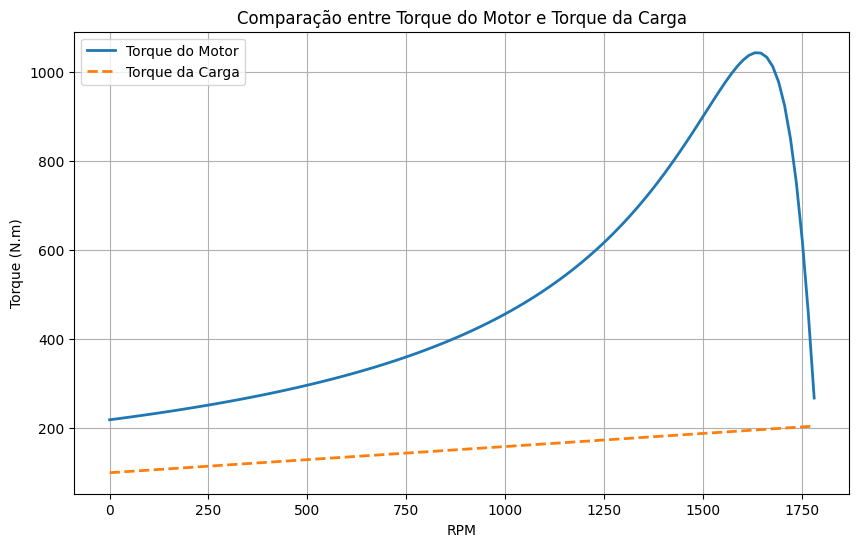

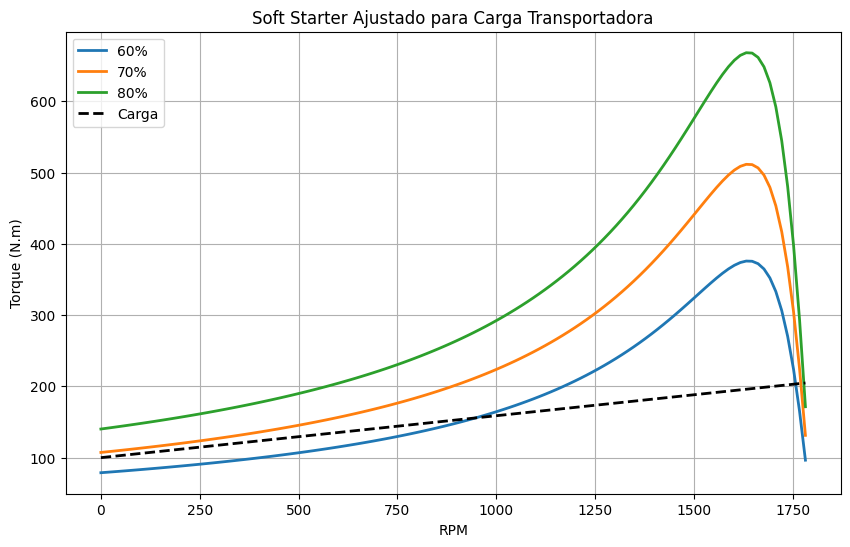

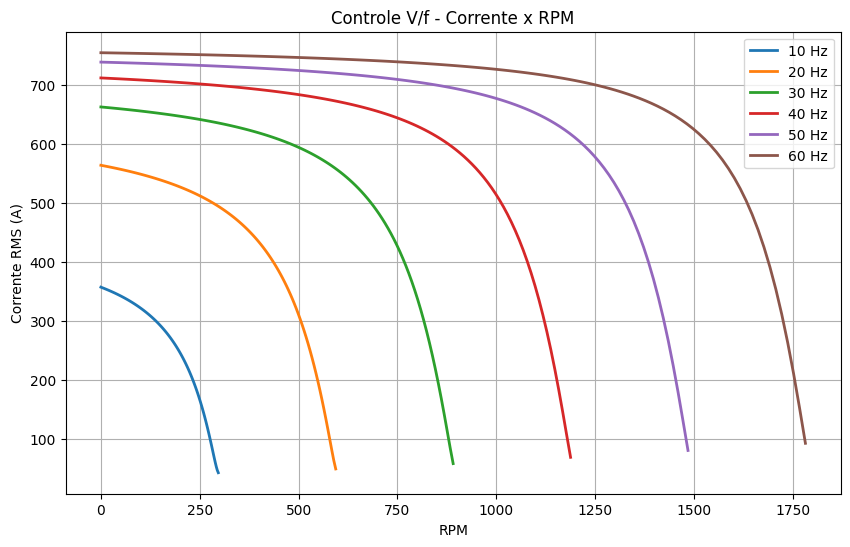

In [8]:
# ============================================================
# FIGURAS FALTANTES PARA O RELATÓRIO
# ============================================================

# ------------------------------------------------------------
# Comparação motor x carga
# ------------------------------------------------------------

rpm_nom, torque_nom, current_nom = model(60, 380, slips)
load = load_curve(rpm_nom)

plt.figure(figsize=(10,6))
plt.plot(rpm_nom, torque_nom, linewidth=2, label='Torque do Motor')
plt.plot(rpm_nom, load, '--', linewidth=2, label='Torque da Carga')
plt.xlabel('RPM')
plt.ylabel('Torque (N.m)')
plt.title('Comparação entre Torque do Motor e Torque da Carga')
plt.legend()
plt.grid()
plt.savefig('comparacao_motor_carga.png', dpi=300)
plt.show()

# ------------------------------------------------------------
# Soft starter ajustado (item 7)
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

for frac in [0.6, 0.7, 0.8]:
    rpm, torque, current = model(
        60,
        380 * frac,
        slips
    )
    plt.plot(rpm, torque, linewidth=2, label=f'{int(frac*100)}%')

plt.plot(rpm_nom, load, 'k--', linewidth=2, label='Carga')

plt.xlabel('RPM')
plt.ylabel('Torque (N.m)')
plt.title('Soft Starter Ajustado para Carga Transportadora')
plt.legend()
plt.grid()
plt.savefig('softstarter_ajustado.png', dpi=300)
plt.show()

# ------------------------------------------------------------
# Controle V/f - Corrente x RPM
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

for f in [10, 20, 30, 40, 50, 60]:
    V = 380 * (f / 60)

    rpm, torque, current = model(
        f,
        V,
        slips
    )

    plt.plot(rpm, current, linewidth=2, label=f'{f} Hz')

plt.xlabel('RPM')
plt.ylabel('Corrente RMS (A)')
plt.title('Controle V/f - Corrente x RPM')
plt.legend()
plt.grid()
plt.savefig('vf_corrente_rpm.png', dpi=300)
plt.show()

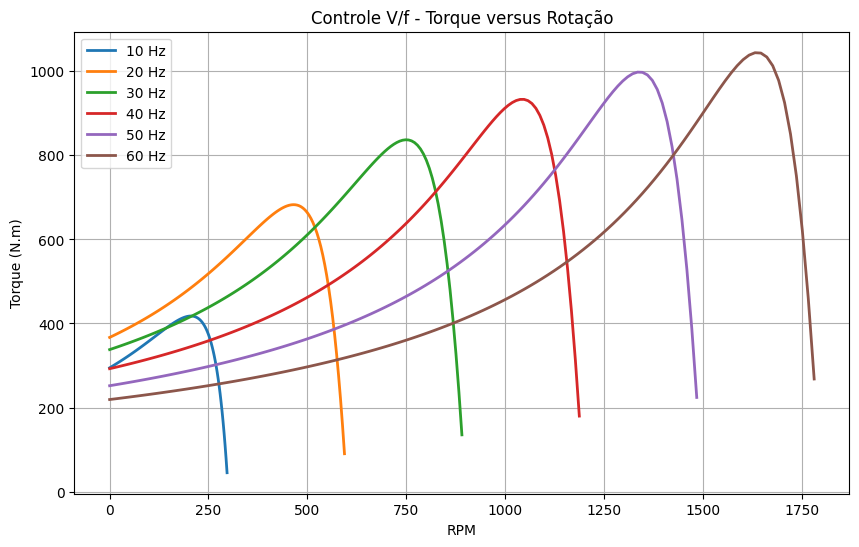

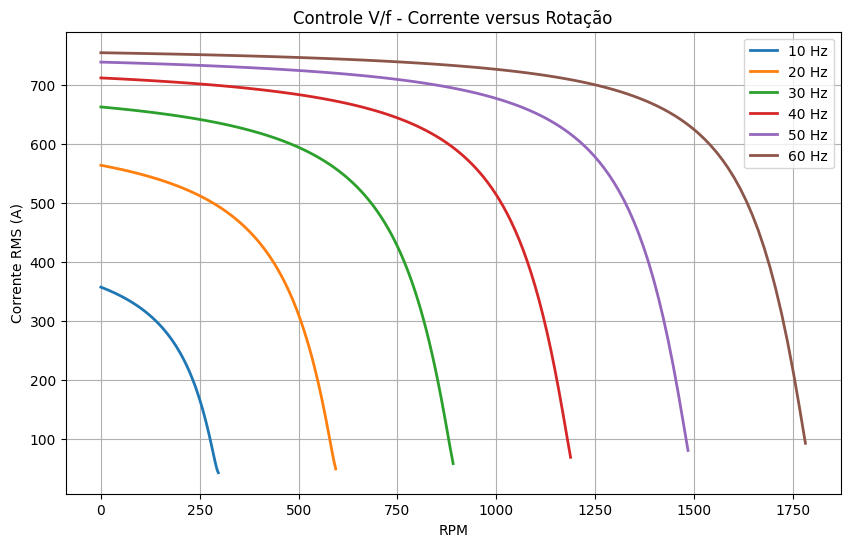

In [9]:
# ============================================================
# CONTROLE V/f - FIGURAS PARA O RELATÓRIO
# ============================================================

# Torque x RPM
plt.figure(figsize=(10,6))

for f in [10, 20, 30, 40, 50, 60]:
    V = 380 * (f / 60)

    rpm, torque, current = model(
        f,
        V,
        slips
    )

    plt.plot(
        rpm,
        torque,
        linewidth=2,
        label=f'{f} Hz'
    )

plt.xlabel('RPM')
plt.ylabel('Torque (N.m)')
plt.title('Controle V/f - Torque versus Rotação')
plt.legend()
plt.grid()
plt.savefig('vf_torque_rpm.png', dpi=300)
plt.show()


# Corrente x RPM
plt.figure(figsize=(10,6))

for f in [10, 20, 30, 40, 50, 60]:
    V = 380 * (f / 60)

    rpm, torque, current = model(
        f,
        V,
        slips
    )

    plt.plot(
        rpm,
        current,
        linewidth=2,
        label=f'{f} Hz'
    )

plt.xlabel('RPM')
plt.ylabel('Corrente RMS (A)')
plt.title('Controle V/f - Corrente versus Rotação')
plt.legend()
plt.grid()
plt.savefig('vf_corrente_rpm.png', dpi=300)
plt.show()

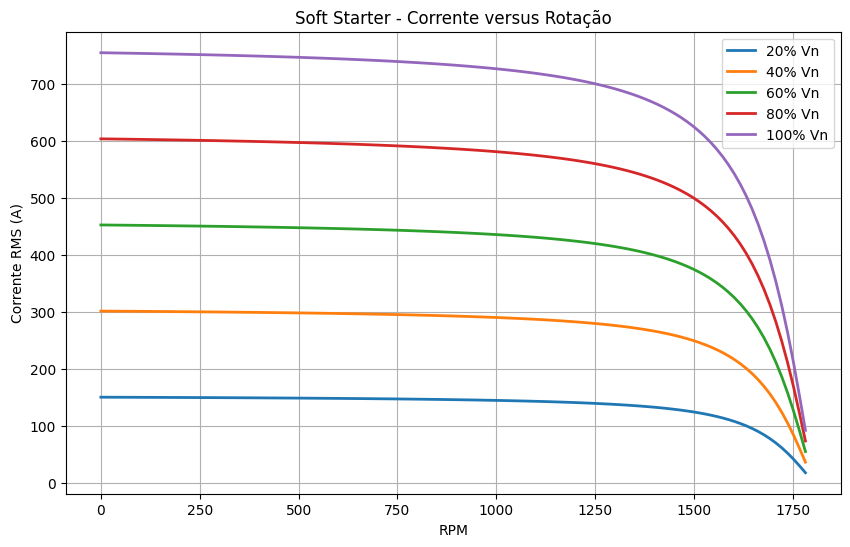

In [11]:
# ============================================================
# SOFT STARTER - CORRENTE x RPM
# ============================================================

plt.figure(figsize=(10,6))

for frac in [0.2, 0.4, 0.6, 0.8, 1.0]:
    rpm, torque, current = model(
        60,
        380 * frac,
        slips
    )

    plt.plot(
        rpm,
        current,
        linewidth=2,
        label=f'{int(frac*100)}% Vn'
    )

plt.xlabel('RPM')
plt.ylabel('Corrente RMS (A)')
plt.title('Soft Starter - Corrente versus Rotação')
plt.legend()
plt.grid()
plt.savefig('softstarter_corrente_rpm.png', dpi=300)
plt.show()

In [14]:
import zipfile
from google.colab import files
import glob
import os

zip_name = 'trabalho_limpo.zip'

arquivos = (
    glob.glob('/content/*.png') +
    glob.glob('/content/*.csv') +
    glob.glob('/content/*.ipynb')
)

with zipfile.ZipFile(zip_name, 'w') as zipf:
    for arq in arquivos:
        zipf.write(arq, os.path.basename(arq))

files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>